5
{'question': "Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?", 'answer': 'Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18'}


model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

Experiment completed.
   id                                           question       prompt_type  \
0   0  Janet’s ducks lay 16 eggs per day. She eats th...         Zero-shot   
1   0  Janet’s ducks lay 16 eggs per day. She eats th...          Few-shot   
2   0  Janet’s ducks lay 16 eggs per day. She eats th...  Chain-of-Thought   
3   1  A robe takes 2 bolts of blue fiber and half th...         Zero-shot   
4   1  A robe takes 2 bolts of blue fiber and half th...          Few-shot   
5   1  A robe takes 2 bolts of blue fiber and half th...  Chain-of-Thought   
6   2  Josh decides to try flipping a house.  He buys...         Zero-shot   
7   2  Josh decides to try flipping a house.  He buys...          Few-shot   
8   2  Josh decides to try flipping a house.  He buys...  Chain-of-Thought   
9   3  James decides to run 3 sprints 3 times a week....         Zero-shot   

                                      model_response true_answer  \
0  \nSolve the following math problem.\nGive only..

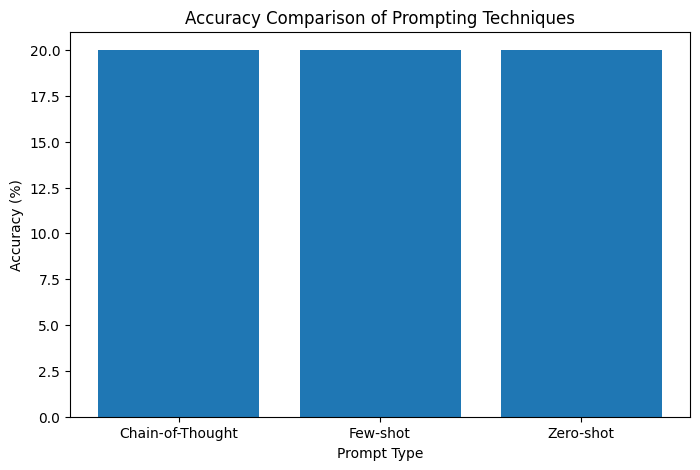

In [5]:
!pip install datasets pandas matplotlib transformers -q

import re
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import pipeline
from google.colab import userdata

dataset = load_dataset("openai/gsm8k", "main")
samples = dataset["test"].select(range(5))

print(len(samples))
print(samples[0])

# Get the Hugging Face token from Colab secrets, if available
# The token is optional for public models but recommended for better rate limits.
try:
    HF_TOKEN = userdata.get('HF_TOKEN')
except userdata.SecretNotFoundError:
    HF_TOKEN = None

generator = pipeline(
    "text-generation",
    model="google/flan-t5-small",
    token=HF_TOKEN
)

def zero_shot_prompt(question):
    return f"""
Solve the following math problem.
Give only the final answer.

Question: {question}
"""

def few_shot_prompt(question):
    return f"""
Solve the following math problems.

Example 1:
Question: Ravi has 3 apples and buys 2 more. How many apples does he have?
Answer: 5

Example 2:The code failed with a `SecretNotFoundError` because the `HF_TOKEN` secret was not found in Colab's secrets, and the `try-except` block was only catching `KeyError`. To fix this, I will modify the `except` clause to specifically catch `SecretNotFoundError`.
Question: There are 4 pencils in one box. If there are 3 boxes, how many pencils are there?
Answer: 12

Now solve this:

Question: {question}
Answer:
"""

def cot_prompt(question):
    return f"""
Solve the following math problem step by step.
Then write the final answer clearly at the end.

Question: {question}
"""

def get_response(prompt):
    output = generator(
        prompt,
        max_length=128,
        do_sample=False
    )
    return output[0]["generated_text"]

def extract_number(text):
    numbers = re.findall(r'-?\d+\.?\d*', text.replace(",", ""))
    if len(numbers) > 0:
        return numbers[-1]
    return None

results = []

for i, sample in enumerate(samples):
    question = sample["question"]
    true_answer_text = sample["answer"]

    true_answer = extract_number(true_answer_text)

    z_prompt = zero_shot_prompt(question)
    z_response = get_response(z_prompt)
    z_pred = extract_number(z_response)

    results.append({
        "id": i,
        "question": question,
        "prompt_type": "Zero-shot",
        "model_response": z_response,
        "true_answer": true_answer,
        "predicted_answer": z_pred
    })

    f_prompt = few_shot_prompt(question)
    f_response = get_response(f_prompt)
    f_pred = extract_number(f_response)

    results.append({
        "id": i,
        "question": question,
        "prompt_type": "Few-shot",
        "model_response": f_response,
        "true_answer": true_answer,
        "predicted_answer": f_pred
    })

    c_prompt = cot_prompt(question)
    c_response = get_response(c_prompt)
    c_pred = extract_number(c_response)

    results.append({
        "id": i,
        "question": question,
        "prompt_type": "Chain-of-Thought",
        "model_response": c_response,
        "true_answer": true_answer,
        "predicted_answer": c_pred
    })

print("Experiment completed.")

df = pd.DataFrame(results)
print(df.head(10))

df["is_correct"] = df["true_answer"] == df["predicted_answer"]
print(df[["id", "prompt_type", "true_answer", "predicted_answer", "is_correct"]])

accuracy_table = df.groupby("prompt_type")["is_correct"].mean() * 100
accuracy_table = accuracy_table.reset_index()
accuracy_table.columns = ["Prompt Type", "Accuracy (%)"]

print(accuracy_table)

plt.figure(figsize=(8, 5))
plt.bar(accuracy_table["Prompt Type"], accuracy_table["Accuracy (%)"])
plt.xlabel("Prompt Type")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Prompting Techniques")
plt.show()